In [1]:
using PEPSKit, TensorKit

### Model Parameters ###
N = 3 #Number of sites in unit cell
n_0 = round(Int, ((N-1)/2))+1 #Index of the point at the center of the lattice (1-based indexing).
m2 = 1 #Bare mass (squared)
m0 = 1 #Basis frequency
l = 0.1 #phi^4 coupling strength
Dim = 4 #Truncated local Hilbert space dimension
d = 2 #Number of spatial dimensions
a = 1 #Lattice spacing

### iPEPS Dimensions ###
Dbond = 3
χ = 24

### Field Operators ###
function a_matrix(D)
    A = zeros(D, D)
    for n in 1:D-1
        A[n, n+1] = sqrt(n)
    end
    return A
end

#Field operator matrices
phi_matrix = D -> (a_matrix(D) + a_matrix(D)')/sqrt(2*m0)
phi2_matrix = D -> phi_matrix(D)^2
phi4_matrix = D -> phi_matrix(D)^4
pi_matrix = D -> im*sqrt(m0/2)*(a_matrix(D)' - a_matrix(D))
pi2_matrix = D -> -(m0 / 2) * ((a_matrix(D)' - a_matrix(D)) * (a_matrix(D)' - a_matrix(D)))

#Truncated Hilbert space (ℂ^D)
V = ComplexSpace(Dim)

#Convert matrices to TensorMap
φ = TensorMap(phi_matrix(Dim), V ← V)
φ2 = TensorMap(phi2_matrix(Dim), V ← V)
φ4 = TensorMap(phi4_matrix(Dim), V ← V)
Π = TensorMap(pi_matrix(Dim), V ← V)
Π2 = TensorMap(pi2_matrix(Dim), V ← V)

### phi4 Hamiltonian ###
function phi4_model(lattice::InfiniteSquare; m2=m2, l=l, a=a, d=d)
    h_site = a^d * ((1/2 * Π2) + (1/a^2 * φ2) + (1/a^2 * φ2) + (1/2 * m2 * φ2) + (l/24 * φ4)) #Onsite Hamiltonian
    h_bond = -1/a^2 * a^d * φ ⊗ φ #Nearest-neighbor interaction Hamiltonian
    spaces = fill(V, (lattice.Nrows, lattice.Ncols))

    return LocalOperator(
        spaces,
        (neighbor => h_bond for neighbor in nearest_neighbours(lattice))...,
        ([idx] => h_site for idx in vertices(lattice))...,
    )
end

H = phi4_model(InfiniteSquare(N, N))

LocalOperator{Any, ComplexSpace}(ComplexSpace[ℂ^4 ℂ^4 ℂ^4; ℂ^4 ℂ^4 ℂ^4; ℂ^4 ℂ^4 ℂ^4], Dict{Vector{CartesianIndex{2}}, Any}([CartesianIndex(3, 3)] => TensorMap{Float64, ComplexSpace, 1, 1, Vector{Float64}}([1.5031249999999998, 0.0, 1.4230523971379268, 0.0, 0.0, 4.515625, 0.0, 2.4647990536755726, 1.4230523971379268, 0.0, 7.528124999999999, 0.0, 0.0, 2.4647990536755726, 0.0, 4.515624999999999], ℂ^4 ← ℂ^4), [CartesianIndex(2, 1), CartesianIndex(3, 1)] => TensorMap{Float64, ComplexSpace, 2, 2, Vector{Float64}}([0.0, 0.0, 0.0, 0.0, 0.0, -0.4999999999999999, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, -1.4999999999999998, 0.0, 0.0, 0.0, 0.0, 0.0], (ℂ^4 ⊗ ℂ^4) ← (ℂ^4 ⊗ ℂ^4)), [CartesianIndex(1, 2)] => TensorMap{Float64, ComplexSpace, 1, 1, Vector{Float64}}([1.5031249999999998, 0.0, 1.4230523971379268, 0.0, 0.0, 4.515625, 0.0, 2.4647990536755726, 1.4230523971379268, 0.0, 7.528124999999999, 0.0, 0.0, 2.4647990536755726, 0.0, 4.515624999999999], ℂ^4 ← ℂ^4), [CartesianIndex(3, 3), CartesianIndex(4,

In [2]:
#= ### Ground state optimization parameters ###
boundary_alg = (; tol = 1e-8, trunc = (; alg = :FixedSpaceTruncation));
optimizer_alg = (; alg = :LBFGS, tol = 1e-4, maxiter = 200, lbfgs_memory = 16);
reuse_env = true
verbosity = 3;

### Initialize PEPS and CTMRG environment
peps₀ = InfinitePEPS(randn, ComplexF64, ℂ^Dim, ℂ^Dbond; unitcell=(N, N))
env_random = CTMRGEnv(randn, ComplexF64, peps₀, ℂ^χ);
env₀, info_ctmrg = leading_boundary(env_random, peps₀; boundary_alg...); =#

In [3]:
#= ### Find the ground state ∣Ω⟩ ###
peps_gs, env_gs, E, info_opt = fixedpoint(H, peps₀, env₀; boundary_alg, optimizer_alg, reuse_env, verbosity); =#

In [4]:
### Load ground state PEPS and CTMRG environment ###
using JLD2
peps_gs = load_object("VacStates/PEPS,N=$N,m2=$m2,l=$l,a=$a,dim=$Dim,D=$Dbond,chi=$χ.jld2")
env_gs = load_object("VacStates/env,N=$N,m2=$m2,l=$l,a=$a,dim=$Dim,D=$Dbond,chi=$χ.jld2")

CTMRGEnv{TensorMap{ComplexF64, ComplexSpace, 1, 1, Vector{ComplexF64}}, TensorMap{ComplexF64, ComplexSpace, 3, 1, Vector{ComplexF64}}}(TensorMap{ComplexF64, ComplexSpace, 1, 1, Vector{ComplexF64}}[TensorMap{ComplexF64, ComplexSpace, 1, 1, Vector{ComplexF64}}(ComplexF64[-0.4841632448618295 + 0.8574199236264521im, -0.00034861973325886545 + 0.0006173816543034287im, 0.005153772393377109 - 0.0018557692004807376im, 0.0019704218919092387 - 0.0034894821240611263im, 0.001735542791431972 - 0.001449751074899822im, 1.4568836835448852e-5 - 2.580041152662646e-5im, 0.00020633592138425197 - 0.0003654067751707175im, -1.5952318908362714e-6 + 7.287396294182e-6im, -6.27775129992723e-5 - 6.92343280791734e-5im, -5.0976247573935055e-5 + 9.027544082495264e-5im  …  -4.437622651837237e-6 - 2.793124285528135e-6im, 1.3840875468729923e-5 + 1.9566775801841228e-5im, 1.636584552909315e-5 - 2.4193825279232424e-5im, -3.83522632385163e-5 - 7.121075640753821e-6im, 5.310887687275292e-5 + 4.639172238354443e-5im, 2.76475119

In [5]:
#Apply φ(0) to ∣Ω⟩
Ω = deepcopy(peps_gs)
Ω.A[n_0, n_0] = φ * Ω.A[n_0, n_0]

4←3×3×3×3 TensorMap{ComplexF64, ComplexSpace, 1, 4, Vector{ComplexF64}}:
 codomain: ⊗(ℂ^4)
 domain: (ℂ^3 ⊗ ℂ^3 ⊗ (ℂ^3)' ⊗ (ℂ^3)')
 blocks: 
 * Trivial() => 4×81 reshape(view(::Vector{ComplexF64}, 1:324), 4, 81) with eltype ComplexF64:
 -0.00586641+0.0154151im  0.00855975+0.0282603im  …  -0.0247116+0.0581428im
   0.0343246-0.0262657im   0.0274361-0.0341326im        0.02895-0.0533275im
 -0.00418324-0.0116411im  -0.0105851+0.0210267im     -0.0150541+0.00504841im
  -0.0057202+0.0103791im  -0.0249015+0.0133936im     -0.0124455+0.0123759im

In [6]:
### Define T₀ᵢ(x) and H(0) ###
T0i_TMap = 1/2 * (φ ⊗ Π - Π ⊗ φ) #Energy flux TensorMap
h_site = a^d * ((1/2 * Π2) + (1/a^2 * φ2) + (1/a^2 * φ2) + (1/2 * m2 * φ2) + (l/24 * φ4)) #Onsite Hamiltonian TensorMap
h_bond = -1/2 * a^d * 1/a^2 * φ ⊗ φ #Nearest-neighbor interaction Hamiltonian TensorMap (split into four directions)

lattice = fill(V, N, N)
T0i = LocalOperator(lattice,
    [(n_0, n_0), (n_0+1, n_0)] => T0i_TMap,
    [(n_0, n_0), (n_0-1, n_0)] => T0i_TMap,
    [(n_0, n_0), (n_0, n_0+1)] => T0i_TMap,
    [(n_0, n_0), (n_0, n_0-1)] => T0i_TMap)
    
H0 = LocalOperator(lattice,
    [(n_0, n_0)] => h_site,
    [(n_0, n_0), (n_0+1, n_0)] => h_bond,
    [(n_0, n_0), (n_0-1, n_0)] => h_bond,
    [(n_0, n_0), (n_0, n_0+1)] => h_bond,
    [(n_0, n_0), (n_0, n_0-1)] => h_bond)

LocalOperator{Any, ComplexSpace}(ComplexSpace[ℂ^4 ℂ^4 ℂ^4; ℂ^4 ℂ^4 ℂ^4; ℂ^4 ℂ^4 ℂ^4], Dict{Vector{CartesianIndex{2}}, Any}([CartesianIndex(2, 2), CartesianIndex(2, 3)] => TensorMap{Float64, ComplexSpace, 2, 2, Vector{Float64}}([0.0, 0.0, 0.0, 0.0, 0.0, -0.24999999999999994, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, -0.7499999999999999, 0.0, 0.0, 0.0, 0.0, 0.0], (ℂ^4 ⊗ ℂ^4) ← (ℂ^4 ⊗ ℂ^4)), [CartesianIndex(2, 2)] => TensorMap{Float64, ComplexSpace, 1, 1, Vector{Float64}}([1.5031249999999998, 0.0, 1.4230523971379268, 0.0, 0.0, 4.515625, 0.0, 2.4647990536755726, 1.4230523971379268, 0.0, 7.528124999999999, 0.0, 0.0, 2.4647990536755726, 0.0, 4.515624999999999], ℂ^4 ← ℂ^4), [CartesianIndex(2, 1), CartesianIndex(2, 2)] => TensorMap{Float64, ComplexSpace, 2, 2, Vector{Float64}}([0.0, 0.0, 0.0, 0.0, 0.0, -0.24999999999999994, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, -0.7499999999999999, 0.0, 0.0, 0.0, 0.0, 0.0], (ℂ^4 ⊗ ℂ^4) ← (ℂ^4 ⊗ ℂ^4)), [CartesianIndex(1, 2), CartesianIndex(2, 2)] => Tenso

In [7]:
### Time evolution parameters ###
ti = 0 #Initial time
tf = 1 #Final time
Δt = 0.1 #Time step size
δt = 0.01 #Trotter step size
nsteps = round(Int, Δt/δt) #Number of steps per trotter evolution
t_range = range(ti, tf, step=Δt) #Time range

0.0:0.1:1.0

In [8]:
### Initialize time evolution (real-time SimpleUpdate) ###
trunc_peps = truncerror(; atol = 1e-10) & truncrank(Dbond)
alg = SimpleUpdate(; trunc = trunc_peps, imaginary_time = false) #Time evolution algorithm
boundary_alg = (; tol = 1e-8, trunc = (; alg = :FixedSpaceTruncation)) #CTMRG boundary algorithm

ψ = Ω
env = env_gs
wts = SUWeight(Ω)

Edens0 = ComplexF64[]
Eflux = ComplexF64[]

### Perform time evolution ###
for i in 1:length(t_range)
    if i == 1 #t=0
        evH = expectation_value(Ω, H0, env_gs)
        evT0i = expectation_value(Ω, T0i, env_gs)
    else #t>0
        ψ, wts = time_evolve(ψ, H, δt, nsteps, alg, wts)
        env, info_ctmrg = leading_boundary(env, ψ; boundary_alg...)

        evH = expectation_value(ψ, H0, env)
        evT0i = expectation_value(ψ, T0i, env)
    end

    push!(Edens0, evH)
    push!(Eflux, evT0i)
end

[ Info: --- Time evolution (simple update), dt = 0.01 ---
[ Info: Space of x-weight at [1, 1] = ℂ^3
[ Info: SU iter 1      : |Δλ| = 1.277e+00. Time = 21.113 s/it
[ Info: Space of x-weight at [1, 1] = ℂ^3
[ Info: SU iter 10     : |Δλ| = 1.024e-04. Time = 0.015 s/it
[ Info: Time evolution finished in 22.29 s
[ Info: CTMRG init:	obj = +4.026501568801e-14	err = 1.0000e+00
[ Info: CTMRG conv 12:	obj = +4.515049121079e+01	err = 6.3078482476e-09	time = 25.61 sec
[ Info: --- Time evolution (simple update), dt = 0.01 ---
[ Info: Space of x-weight at [1, 1] = ℂ^3
[ Info: SU iter 1      : |Δλ| = 1.100e-04. Time = 0.018 s/it
[ Info: Space of x-weight at [1, 1] = ℂ^3
[ Info: SU iter 10     : |Δλ| = 1.605e-04. Time = 0.030 s/it
[ Info: Time evolution finished in 0.20 s
[ Info: CTMRG init:	obj = +5.328884862424e+01	err = 1.0000e+00
[ Info: CTMRG conv 9:	obj = +5.329987226090e+01	err = 1.8790051243e-09	time = 12.47 sec
[ Info: --- Time evolution (simple update), dt = 0.01 ---
[ Info: Space of x-weight

In [9]:
#= ### Save Data ###
data = h5open("2d_EEC_data/EVs,N=$N,a=$a,l=$l,m=$m2,ti=$ti,tf=$tf", "w")
data["Edens0"] = Edens0
data["Eflux"] = Eflux
close(data) =#

In [10]:
function CalcEdensOut(t_ind)
    s_range = range(1, t_ind-1)
    Edens = 0
    for s_ind in s_range
        Edens += 1/2*Δt*(Eflux[s_ind]+Eflux[s_ind+1])
    end
    return Edens
end

EdensTot = [Edens0[t_ind] + CalcEdensOut(t_ind) for t_ind in 1:length(t_range)]
residuals = EdensTot .- Edens0[1]

11-element Vector{ComplexF64}:
                    0.0 + 0.0im
 -0.0003420900644481861 + 9.839526927760911e-16im
   0.006496665103893351 - 1.370587050929743e-15im
    0.03201617380140798 - 2.283139954221502e-16im
    0.07929754294025892 + 6.457625515649722e-20im
     0.1389721428024504 + 5.290984196189344e-16im
    0.19558633624923183 - 5.512470368688704e-16im
     0.2390505107094878 + 7.152304212501292e-17im
      4.441774034298343 - 5.3441401840104064e-15im
      5.384261338900747 + 2.7422444838405166e-15im
      5.842282202928496 - 6.219650151369274e-16im

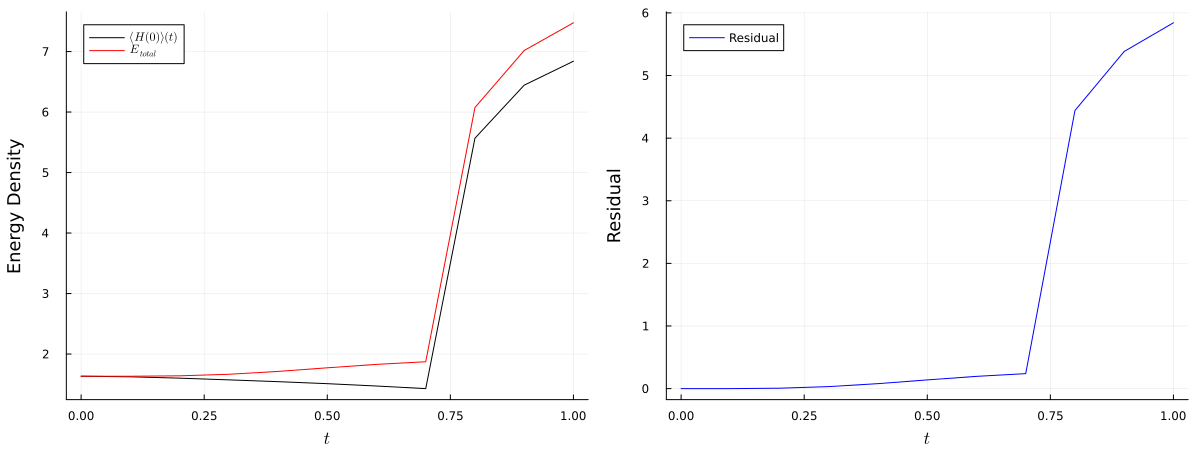

In [11]:
using Plots, Plots.PlotMeasures

Edens_plt = plot(t_range, real(Edens0),
    guidefont=font(12),
    xlabel="\$t\$",
    ylabel="Energy Density",
    size=(600, 450),
    color="black",
    label="\$⟨{H(0)}⟩(t)\$")
plot!(t_range, real(EdensTot), color="red", label="\$E_{total}\$")

res_plt = plot(t_range, real(residuals), color="blue", label="Residual")

plot(Edens_plt, res_plt, layout=(1,2),
    guidefont=font(12),
    xlabel=["\$t\$" "\$t\$"],
    ylabel=["Energy Density" "Residual"],
    size=(1200, 450), 
    bottom_margin=18px,
    left_margin=25px)
#savefig("Plots/Energy Conservation, N=5, m=1, lambda=1e-1, truncated HS dim=10")